In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import torch
from torch import nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score

from lite_org import LITE
from inception import Classifier_INCEPTION

from utils import load_data, preprocess_data
import os
from  utils import *

import warnings
warnings.filterwarnings('ignore')

In [2]:
from torch.cuda.amp import autocast

def evaluate_ensemble_base(models, dataloader):
    models = [model.eval() for model in models]
    models = [model.cuda() for model in models]
    
    all_preds = []
    all_targets = []

    with torch.no_grad():

        for data, target in dataloader:
            data, target = data.cuda(), target.cuda()

            outputs = [model(data.float())[0] for model in models]
            probs = [F.softmax(output, dim=1) for output in outputs]
            
            avg_probs = sum(probs) / len(probs)

            preds = avg_probs.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(target.cpu().numpy())

    accuracy = accuracy_score(all_targets, all_preds)
    return accuracy



def evaluate_ensemble_base_inception(models, dataloader):
    models = [model.eval() for model in models]
    models = [model.cuda() for model in models]
    
    all_preds = []
    all_targets = []

    with torch.no_grad():

        for data, target in dataloader:
            data, target = data.cuda(), target.cuda()

            outputs = [model(data.float()) for model in models]
            probs = [F.softmax(output, dim=1) for output in outputs]
            
            avg_probs = sum(probs) / len(probs)

            preds = avg_probs.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(target.cpu().numpy())

    accuracy = accuracy_score(all_targets, all_preds)
    return accuracy

In [ ]:
dataset_names = [ 
                    'ACSF1', 'Adiac', 'AllGestureWiimoteX', 'AllGestureWiimoteY', 'AllGestureWiimoteZ',
                    'ArrowHead', 'BeetleFly', 'BirdChicken', 'Beef',  'BME', 'Car', 'CBF', 'Chinatown',
                    'ChlorineConcentration', 'CinCECGTorso', 'Coffee', 'Computers', 'CricketX',
                    'CricketY', 'CricketZ', 
                    'DiatomSizeReduction',
                    'DistalPhalanxOutlineAgeGroup', 'DistalPhalanxOutlineCorrect', 'DistalPhalanxTW',
                    'DodgerLoopDay', 'DodgerLoopGame', 'DodgerLoopWeekend', 'Earthquakes', 'ECG200',
                    'ECG5000', 'ECGFiveDays',  'EOGHorizontalSignal', 'EthanolLevel', 
                    'EOGVerticalSignal',  'FaceAll', 'FaceFour', 'FacesUCR',
                    'FiftyWords', 'Fish', 'FreezerRegularTrain',
                    'FreezerSmallTrain', 'Fungi', 'GestureMidAirD1', 'GestureMidAirD2',
                    'GestureMidAirD3', 'GesturePebbleZ1', 'GesturePebbleZ2', 'GunPoint',
                    'GunPointAgeSpan', 'GunPointMaleVersusFemale', 'GunPointOldVersusYoung',
                    'Ham',  'Haptics', 'Herring', 'HouseTwenty', 'InlineSkate',
                    'InsectEPGRegularTrain', 'InsectEPGSmallTrain', 'InsectWingbeatSound',
                    'ItalyPowerDemand', 'LargeKitchenAppliances', 'Lightning2', 'Lightning7',
                    'Mallat', 'Meat', 'MedicalImages', 'MelbournePedestrian',
                    'MiddlePhalanxOutlineAgeGroup', 'MiddlePhalanxOutlineCorrect',
                    'MiddlePhalanxTW', 'MixedShapesRegularTrain', 'MixedShapesSmallTrain',
                    'MoteStrain', 'NonInvasiveFetalECGThorax1', 'NonInvasiveFetalECGThorax2',
                    'OliveOil', 'OSULeaf', 'PhalangesOutlinesCorrect', 'Phoneme',
                    'PickupGestureWiimoteZ', 'PigAirwayPressure', 'PigArtPressure', 'PigCVP',
                    'PLAID', 'Plane', 'PowerCons', 'ProximalPhalanxOutlineAgeGroup',
                    'ProximalPhalanxOutlineCorrect', 'ProximalPhalanxTW', 'RefrigerationDevices',
                    'Rock', 'ScreenType', 'SemgHandGenderCh2', 'SemgHandMovementCh2',
                    'SemgHandSubjectCh2', 'ShakeGestureWiimoteZ', 'ShapeletSim', 'ShapesAll',
                    'SmallKitchenAppliances', 'SmoothSubspace', 'SonyAIBORobotSurface1',
                    'SonyAIBORobotSurface2', 'StarLightCurves', 'Strawberry', 'SwedishLeaf',
                    'Symbols', 'SyntheticControl', 'ToeSegmentation1', 'ToeSegmentation2', 'Trace',
                    'TwoLeadECG', 'TwoPatterns', 'UMD', 'UWaveGestureLibraryAll',
                    'UWaveGestureLibraryX', 'UWaveGestureLibraryY', 'Wine', 'WordSynonyms', 'Yoga', 
                    'UWaveGestureLibraryZ', 'Wafer',  'Worms', 'WormsTwoClass',     
                                    
                    'Crop', 'ElectricDevices',  'FordA', 'FordB', 'HandOutlines',
                    
                    ]

columns=['Dataset', 'base_ens_acc', 'base_params', 'pretrained_ens_acc', 'pretrained_params', 'pruned_ens_acc', 'pruned_params',
         'finetuned_ens_acc', 'finetuned_params', 'scratch_ens_acc', 'scratch_params' ]

tmp_df = pd.DataFrame(columns=columns)
seeds = [9409, 5296, 3952, 3804, 2561]

for dataset in dataset_names:
    rows = [dataset]
    models_base, models_pretrained, models_pruned, models_finetuned, models_scratch_trained = [], [], [], [], []
    base_params, pretrained_params, pruned_params, finetuned_params, scratch_params = 0, 0, 0, 0, 0
    
    for seed in seeds:
        xtrain, ytrain, xtest, ytest = load_data(file_name=dataset)
        trainloader = preprocess_data(xtrain, ytrain, mini_batch_size=64)
        testloader = preprocess_data(xtest, ytest, mini_batch_size=64)

        length_TS = int(xtrain.shape[1])
        n_classes = len(np.unique(ytrain))

        model_base = LITE(output_directory=None, length_TS=length_TS, n_classes=n_classes, n_filters=[[32, 32, 32], 32, 32])
        model_base.load_state_dict(torch.load(os.getcwd() +  f'/results/base_models_32_filters/base_seed_{seed}/{dataset}/best_model.pt'))
        base_params += sum(p.numel() for p in model_base.parameters())
        model_base.cuda()
        model_base.eval()
        models_base.append(model_base)
            
        model_pretrained = LITE(output_directory=None, length_TS=length_TS, n_classes=n_classes, n_filters=[[32, 32, 32], 32, 32])
        model_pretrained.load_state_dict(torch.load(os.getcwd() + f'/results/base_models_1e-5_weights_4_2_1/ins_sparse_seed_{seed}/{dataset}/best_model.pt'))
        models_pretrained.append(model_pretrained)
        pretrained_params += sum(p.numel() for p in model_pretrained.parameters())
        
        
        model_pruned = torch.load(os.getcwd() + f'/results/base_models_1e-5_weights_4_2_1/ins_sparse_seed_{seed}/{dataset}/pruned_model.pth')
        models_pruned.append(model_pruned)
        pruned_params += sum(p.numel() for p in model_pruned.parameters())
        
        model_finetuned = torch.load(os.getcwd() + f'/results/finetune_1e-5_weights_4_2_1_with_lr_scheduler_epochs_500/ins_sparse_seed_{seed}/{dataset}/best_model.pth')
        models_finetuned.append(model_finetuned)
        finetuned_params += sum(p.numel() for p in model_finetuned.parameters())
        
        model_scratch_trained = torch.load(os.getcwd() + f'/results/scratch_training_1e-5_weights_4_2_1_epochs_1500/ins_sparse_seed_{seed}/{dataset}/best_model.pth')
        models_scratch_trained.append(model_scratch_trained)
        scratch_params += sum(p.numel() for p in model_scratch_trained.parameters())
        
        
        # model_prune_dynamic = torch.load(os.getcwd() + f'/results/scratch_training_1e-5_weights_4_2_1_epochs_1500/ins_sparse_seed_{seed}/{dataset}/best_model.pth')
        # model_prune_dynamic = torch.load(os.getcwd() + f'/results/finetune_1e-5_weights_4_2_1_with_lr_scheduler_epochs_500/ins_sparse_seed_{seed}/{dataset}/best_model.pth')


    
    base_ens_acc = evaluate_ensemble_base(models_base, testloader)     
    rows.append(base_ens_acc)
    rows.append(base_params / 5)
              
    pretrained_ens_acc = evaluate_ensemble_base(models_pretrained, testloader)     
    rows.append(pretrained_ens_acc)
    rows.append(pretrained_params / 5)

    pruned_ens_acc = evaluate_ensemble_base(models_pruned, testloader)     
    rows.append(pruned_ens_acc)
    rows.append(pruned_params / 5)
    
    finetuned_ens_acc = evaluate_ensemble_base(models_finetuned, testloader)     
    rows.append(finetuned_ens_acc)
    rows.append(finetuned_params / 5)
    
    scratch_ens_acc = evaluate_ensemble_base(models_scratch_trained, testloader)     
    rows.append(scratch_ens_acc)
    rows.append(scratch_params / 5)



    tmp_df = pd.concat([tmp_df, pd.DataFrame([rows], columns=columns)])
    print('Dataset: ', dataset)   

In [10]:
# tmp_df.to_csv('lite_5_models_mcm.csv', index=False)

p_value:  4.301794787208193e-14


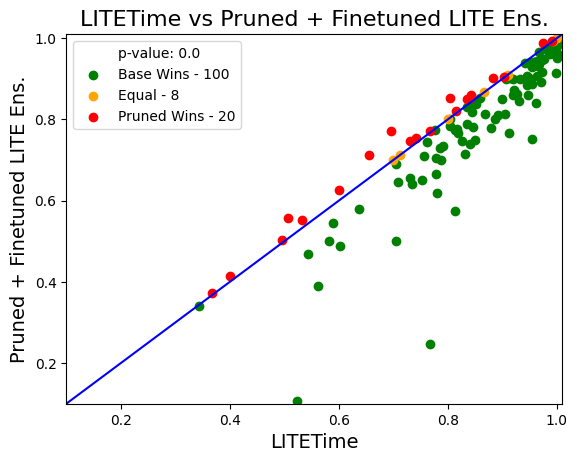

In [4]:
from utils import plot_1v1_perf
from scipy.stats import wilcoxon

# Perform the Wilcoxon signed-rank test
stat, p_value = wilcoxon(tmp_df['base_ens_acc'].tolist(), tmp_df['prune_dynamic_ens_acc'])
print('p_value: ', p_value)

plot_1v1_perf(tmp_df, 
              np.round(p_value, 5), 
              x_y_lim=0.1, 
              acc_base=1.01, 
              co_col='prune_dynamic_ens_acc', 
              base_col='base_ens_acc', 
              xlabel='LITETime', 
              ylabel='Pruned + Finetuned LITE Ens.', 
              legend_base='Base', 
              legend_co='Pruned', 
              title='LITETime vs Pruned + Finetuned LITE Ens.', 
              file_name='fig_1')

In [ ]:
dataset_names = [ 
                    'ACSF1', 'Adiac', 'AllGestureWiimoteX', 'AllGestureWiimoteY', 'AllGestureWiimoteZ',
                    'ArrowHead', 'BeetleFly', 'BirdChicken', 'Beef',  'BME', 'Car', 'CBF', 'Chinatown',
                    'ChlorineConcentration', 'CinCECGTorso', 'Coffee', 'Computers', 'CricketX',
                    'CricketY', 'CricketZ', 
                    'DiatomSizeReduction',
                    'DistalPhalanxOutlineAgeGroup', 'DistalPhalanxOutlineCorrect', 'DistalPhalanxTW',
                    'DodgerLoopDay', 'DodgerLoopGame', 'DodgerLoopWeekend', 'Earthquakes', 'ECG200',
                    'ECG5000', 'ECGFiveDays',  'EOGHorizontalSignal', 'EthanolLevel', 
                    'EOGVerticalSignal',  'FaceAll', 'FaceFour', 'FacesUCR',
                    'FiftyWords', 'Fish', 'FreezerRegularTrain',
                    'FreezerSmallTrain', 'Fungi', 'GestureMidAirD1', 'GestureMidAirD2',
                    'GestureMidAirD3', 'GesturePebbleZ1', 'GesturePebbleZ2', 'GunPoint',
                    'GunPointAgeSpan', 'GunPointMaleVersusFemale', 'GunPointOldVersusYoung',
                    'Ham',  'Haptics', 'Herring', 'HouseTwenty', 'InlineSkate',
                    'InsectEPGRegularTrain', 'InsectEPGSmallTrain', 'InsectWingbeatSound',
                    'ItalyPowerDemand', 'LargeKitchenAppliances', 'Lightning2', 'Lightning7',
                    'Mallat', 'Meat', 'MedicalImages', 'MelbournePedestrian',
                    'MiddlePhalanxOutlineAgeGroup', 'MiddlePhalanxOutlineCorrect',
                    'MiddlePhalanxTW', 'MixedShapesRegularTrain', 'MixedShapesSmallTrain',
                    'MoteStrain', 'NonInvasiveFetalECGThorax1', 'NonInvasiveFetalECGThorax2',
                    'OliveOil', 'OSULeaf', 'PhalangesOutlinesCorrect', 'Phoneme',
                    'PickupGestureWiimoteZ', 'PigAirwayPressure', 'PigArtPressure', 'PigCVP',
                    'PLAID', 'Plane', 'PowerCons', 'ProximalPhalanxOutlineAgeGroup',
                    'ProximalPhalanxOutlineCorrect', 'ProximalPhalanxTW', 'RefrigerationDevices',
                    'Rock', 'ScreenType', 'SemgHandGenderCh2', 'SemgHandMovementCh2',
                    'SemgHandSubjectCh2', 'ShakeGestureWiimoteZ', 'ShapeletSim', 'ShapesAll',
                    'SmallKitchenAppliances', 'SmoothSubspace', 'SonyAIBORobotSurface1',
                    'SonyAIBORobotSurface2', 'StarLightCurves', 'Strawberry', 'SwedishLeaf',
                    'Symbols', 'SyntheticControl', 'ToeSegmentation1', 'ToeSegmentation2', 'Trace',
                    'TwoLeadECG', 'TwoPatterns', 'UMD', 'UWaveGestureLibraryAll',
                    'UWaveGestureLibraryX', 'UWaveGestureLibraryY', 'Wine', 'WordSynonyms', 'Yoga', 
                    'UWaveGestureLibraryZ', 'Wafer',  'Worms', 'WormsTwoClass',     
                                    
                    'Crop', 'ElectricDevices',  'FordA', 'FordB', 'HandOutlines',
                    
                    ]

columns=['Dataset', 'base_ens_acc', 'base_params', 'pretrained_ens_acc', 'pretrained_params', 'pruned_ens_acc', 'pruned_params',
         'finetuned_ens_acc', 'finetuned_params', 'scratch_ens_acc', 'scratch_params' ]

columns=['Dataset', 'base_ens_acc', 'base_params', 'pruned_ens_acc', 'pruned_params',]
tmp_df = pd.DataFrame(columns=columns)
seeds = [9409, 5296, 3952, 3804, 2561]

for dataset in dataset_names:
    rows = [dataset]
    models_base, models_pretrained, models_pruned, models_finetuned, models_scratch_trained = [], [], [], [], []
    base_params, pretrained_params, pruned_params, finetuned_params, scratch_params = 0, 0, 0, 0, 0
    
    for seed in seeds:
        xtrain, ytrain, xtest, ytest = load_data(file_name=dataset)
        trainloader = preprocess_data(xtrain, ytrain, mini_batch_size=64)
        testloader = preprocess_data(xtest, ytest, mini_batch_size=64)

        length_TS = int(xtrain.shape[1])
        n_classes = len(np.unique(ytrain))

        input_shape = xtrain.shape[1:]
        nb_classes = len(np.unique(ytrain))

        model_base = Classifier_INCEPTION(input_shape, nb_classes, nb_filters=np.array([[32, 32, 32, 32],
                                                                                        [32, 32, 32, 32],
                                                                                        [32, 32, 32, 32],
                                                                                        [32, 32, 32, 32],
                                                                                        [32, 32, 32, 32],
                                                                                        [32, 32, 32, 32]]),)        
        
        model_base.load_state_dict(torch.load(os.getcwd() + f'/results_inception/base_models/base_seed_{seed}/{dataset}/best_model.pt'))
        base_params += sum(p.numel() for p in model_base.parameters())
        model_base.cuda()
        model_base.eval()
        models_base.append(model_base)
            
        # model_pretrained = Classifier_INCEPTION(input_shape, nb_classes, nb_filters=np.array([[32, 32, 32, 32],
        #                                                                                 [32, 32, 32, 32],
        #                                                                                 [32, 32, 32, 32],
        #                                                                                 [32, 32, 32, 32],
        #                                                                                 [32, 32, 32, 32],
        #                                                                                 [32, 32, 32, 32]]),)        
        # model_pretrained.load_state_dict(torch.load(os.getcwd() + f'/results_inception/base_models_1e-5_weights_4_2_1/ins_sparse_seed_{seed}/{dataset}/best_model.pt'))
        # models_pretrained.append(model_pretrained)
        # pretrained_params += sum(p.numel() for p in model_pretrained.parameters())
        

        
        model_scratch_trained = torch.load(os.getcwd() + f'/results_inception/scratch_training_1e-5_weights_1_1_1_epochs_1500/ins_sparse_seed_{seed}/{dataset}/best_model.pth')
        models_scratch_trained.append(model_scratch_trained)
        scratch_params += sum(p.numel() for p in model_scratch_trained.parameters())
        
        
    
    base_ens_acc = evaluate_ensemble_base_inception(models_base, testloader)     
    rows.append(base_ens_acc)
    rows.append(base_params / 5)
              
    # pretrained_ens_acc = evaluate_ensemble_base_inception(models_pretrained, testloader)     
    # rows.append(pretrained_ens_acc)
    # rows.append(pretrained_params / 5)

    # pruned_ens_acc = evaluate_ensemble_base_inception(models_pruned, testloader)     
    # rows.append(pruned_ens_acc)
    # rows.append(pruned_params / 5)
    
    # finetuned_ens_acc = evaluate_ensemble_base_inception(models_finetuned, testloader)     
    # rows.append(finetuned_ens_acc)
    # rows.append(finetuned_params / 5)
    
    scratch_ens_acc = evaluate_ensemble_base_inception(models_scratch_trained, testloader)     
    rows.append(scratch_ens_acc)
    rows.append(scratch_params / 5)



    tmp_df = pd.concat([tmp_df, pd.DataFrame([rows], columns=columns)])
    print('Dataset: ', dataset)   

p_value:  0.104013683294396


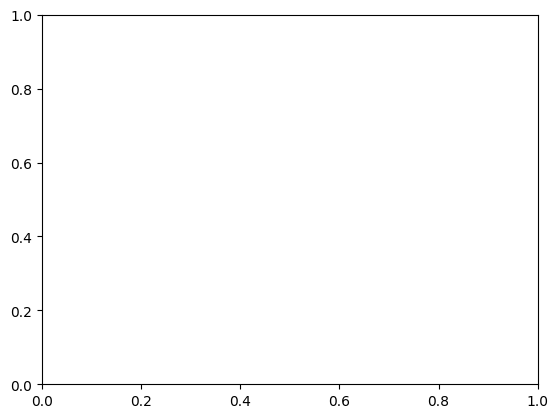

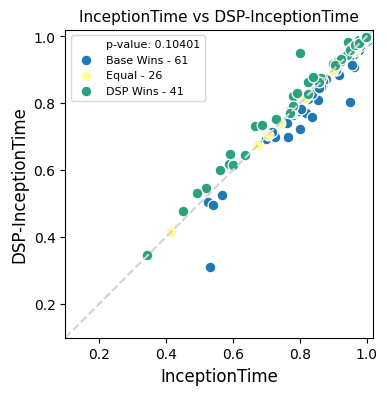

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from scipy.stats import wilcoxon

from matplotlib import rc_context


def plot_1v1_perf(res_df, p_value, x_y_lim=0, acc_base=1, co_col='ens_co', base_col='base_ens',
                  xlabel='base perf.', ylabel='CoTrain perf.', legend_base='Base', legend_co='CoTrain',
                  title='Title', file_name=None):

    plt.xlim(0, 1); plt.ylim(0, 1)
    
    x_line = [x_y_lim, acc_base]
    y_line = [x_y_lim, acc_base]


    x_scatter = res_df[base_col].tolist()
    y_scatter = res_df[co_col].tolist()

    x_above = np.array([x for x, y in zip(x_scatter, y_scatter) if y > x])
    y_above = np.array([y for x, y in zip(x_scatter, y_scatter) if y > x])

    x_same = np.array([x for x, y in zip(x_scatter, y_scatter) if y == x])
    y_same = np.array([y for x, y in zip(x_scatter, y_scatter) if y == x])

    x_below = np.array([x for x, y in zip(x_scatter, y_scatter) if y < x])
    y_below = np.array([y for x, y in zip(x_scatter, y_scatter) if y < x])

    plt.figure(figsize=(4, 4))
    plt.plot(x_line, y_line, color='lightgray', linestyle='--')

    num_wins = res_df[res_df[co_col] > res_df[base_col]].shape[0]
    num_ties = res_df[res_df[co_col] == res_df[base_col]].shape[0]
    num_losses = res_df[res_df[co_col] < res_df[base_col]].shape[0]

    plt.scatter([], [], label=f'p-value: {p_value}', color='none')

    # Pastel colors with white circular border
    plt.scatter(x_below, y_below, label=f'{legend_base} Wins - {num_losses}',
                color='#77DD77', edgecolors='white', linewidths=0.9, s=60, alpha=1)
    plt.scatter(x_same, y_same, label=f'Equal - {num_ties}',
                color='#FDFD96', edgecolors='white', linewidths=0.9, s=60, alpha=1)
    plt.scatter(x_above, y_above, label=f'{legend_co} Wins - {num_wins}',
                color='#FF6961', edgecolors='white', linewidths=0.9, s=60, alpha=1)

    plt.xlim(x_y_lim, acc_base)
    plt.ylim(x_y_lim, acc_base)
    plt.gca().set_aspect('equal', adjustable='box')  # Square aspect

    plt.xlabel(xlabel, fontsize=10)
    plt.ylabel(ylabel, fontsize=10)
    plt.title(title, fontsize=10)
    
    plt.legend(fontsize=8)
    if file_name:
        plt.savefig(f'{file_name}.pdf', bbox_inches='tight', pad_inches=0)

    
    
    # plt.show()

def plot_1v1_perf(res_df, p_value, x_y_lim=0, acc_base=1, co_col='ens_co', base_col='base_ens',
                  xlabel='base perf.', ylabel='CoTrain perf.', legend_base='Base', legend_co='CoTrain',
                  title='Title', file_name=None):

    plt.xlim(0, 1); plt.ylim(0, 1)
    
    x_line = [x_y_lim, acc_base]
    y_line = [x_y_lim, acc_base]


    x_scatter = res_df[base_col].tolist()
    y_scatter = res_df[co_col].tolist()

    x_above = np.array([x for x, y in zip(x_scatter, y_scatter) if y > x])
    y_above = np.array([y for x, y in zip(x_scatter, y_scatter) if y > x])

    x_same = np.array([x for x, y in zip(x_scatter, y_scatter) if y == x])
    y_same = np.array([y for x, y in zip(x_scatter, y_scatter) if y == x])

    x_below = np.array([x for x, y in zip(x_scatter, y_scatter) if y < x])
    y_below = np.array([y for x, y in zip(x_scatter, y_scatter) if y < x])

    plt.figure(figsize=(4, 4))
    plt.plot(x_line, y_line, color='lightgray', linestyle='--')


    num_wins = res_df[res_df[co_col] > res_df[base_col]].shape[0]
    num_ties = res_df[res_df[co_col] == res_df[base_col]].shape[0]
    num_losses = res_df[res_df[co_col] < res_df[base_col]].shape[0]

    plt.scatter([], [], label=f'p-value: {p_value}', color='none')

    color1 = (31/255, 119/255, 180/255)  # RGB (31,119,180)
    color2 = (44/255, 161/255, 127/255)  # RGB (44,161,127)

    # Pastel colors with white circular border
    plt.scatter(x_below, y_below, label=f'{legend_base} Wins - {num_losses}',
                color=color1, edgecolors='white', linewidths=0.9, s=60, alpha=1)
    plt.scatter(x_same, y_same, label=f'Equal - {num_ties}',
                color='#FDFD96', edgecolors='white', linewidths=0.9, s=60, alpha=1)
    plt.scatter(x_above, y_above, label=f'{legend_co} Wins - {num_wins}',
                color=color2, edgecolors='white', linewidths=0.9, s=60, alpha=1)

    plt.xlim(x_y_lim, acc_base)
    plt.ylim(x_y_lim, acc_base)
    plt.gca().set_aspect('equal', adjustable='box')  # Square aspect

    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.title(title, fontsize=11)
    
    plt.legend(fontsize=8)
    if file_name:
        plt.savefig(f'{file_name}.pdf', bbox_inches='tight', pad_inches=0)

    
    
    
# df = pd.read_csv(os.getcwd() + '/results.csv')

df = tmp_df
# Perform the Wilcoxon signed-rank test
stat, p_value = wilcoxon(df['base_ens_acc'].tolist(), df['pruned_ens_acc'])
print('p_value: ', p_value)


plot_1v1_perf(df, 
              np.round(p_value, 5), 
              x_y_lim=0.1, 
              acc_base=1.02, 
              co_col='pruned_ens_acc', 
              base_col='base_ens_acc', 
              xlabel='InceptionTime', 
              ylabel='DSP-InceptionTime', 
              legend_base='Base', 
              legend_co='DSP', 
              title='InceptionTime vs DSP-InceptionTime', 
              file_name='inc_1v1_comp_upt_4')

In [14]:
# tmp_df.to_csv('inception_5_models_mcm.csv', index=False)

In [13]:
tmp_df

,Dataset,base_ens_acc,base_params,pruned_ens_acc,pruned_params
0,ACSF1,0.930000,421482.0,0.940000,86869.0
0,Adiac,0.849105,424965.0,0.841432,267427.8
0,AllGestureWiimoteX,0.780000,421482.0,0.765714,116700.6
0,AllGestureWiimoteY,0.830000,421482.0,0.817143,143204.2
0,AllGestureWiimoteZ,0.792857,421482.0,0.771429,106478.4
...,...,...,...,...,...
0,Crop,0.771012,423288.0,0.772440,253932.6
0,ElectricDevices,0.716639,421095.0,0.714175,197250.6
0,FordA,0.962879,420450.0,0.956061,52433.0
0,FordB,0.856790,420450.0,0.845679,57966.2


In [16]:
tmp_df['diff'] = tmp_df['pruned_ens_acc'] - tmp_df['base_ens_acc']

In [20]:
tmp_df.sort_values(['diff'], ascending=True)[:15]

,Dataset,base_ens_acc,base_params,pruned_ens_acc,pruned_params,diff
0,PigAirwayPressure,0.533654,426900.0,0.312500,30031.2,-0.221154
0,UWaveGestureLibraryAll,0.950028,421224.0,0.802624,37011.4,-0.147404
0,SemgHandSubjectCh2,0.802222,420837.0,0.722222,109438.2,-0.080000
0,SemgHandGenderCh2,0.836667,420450.0,0.760000,27651.8,-0.076667
0,OliveOil,0.766667,420708.0,0.700000,66275.2,-0.066667
0,DistalPhalanxOutlineAgeGroup,0.762590,420579.0,0.697842,90299.8,-0.064748
0,PigCVP,0.961538,426900.0,0.908654,32175.8,-0.052885
0,Lightning2,0.819672,420450.0,0.770492,98339.6,-0.049180
0,GesturePebbleZ2,0.854430,420966.0,0.810127,120101.0,-0.044304
0,HandOutlines,0.956757,420450.0,0.913514,10122.2,-0.043243


In [21]:
ucr_df = pd.read_csv('/home/jabdullayev/phd/datasets/ucr_summary.csv')

In [22]:
res_df = pd.merge(tmp_df, ucr_df, left_on='Dataset', right_on='Name')

In [23]:
res_df

,Dataset,base_ens_acc,base_params,pruned_ens_acc,pruned_params,diff,ID,Type,Name,Train,Test,Class,Length,ED (w=0),DTW (learned_w),DTW (w=100),Default rate,Data donor/editor
0,ACSF1,0.930000,421482.0,0.940000,86869.0,0.010000,86,Device,ACSF1,100,100,10,1460,0.4600,0.3800 (4),0.3600,0.9000,P. Schafer
1,Adiac,0.849105,424965.0,0.841432,267427.8,-0.007673,1,Image,Adiac,390,391,37,176,0.3887,0.3913 (3),0.3964,0.9591,A. Jalba
2,AllGestureWiimoteX,0.780000,421482.0,0.765714,116700.6,-0.014286,87,Sensor,AllGestureWiimoteX,300,700,10,Vary,0.4843,0.2829 (14),0.2843,0.9000,J. Guna
3,AllGestureWiimoteY,0.830000,421482.0,0.817143,143204.2,-0.012857,88,Sensor,AllGestureWiimoteY,300,700,10,Vary,0.4314,0.2700 (9),0.2714,0.9000,J. Guna
4,AllGestureWiimoteZ,0.792857,421482.0,0.771429,106478.4,-0.021429,89,Sensor,AllGestureWiimoteZ,300,700,10,Vary,0.5457,0.3486 (11),0.3571,0.9000,J. Guna
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,Crop,0.771012,423288.0,0.772440,253932.6,0.001429,92,Image,Crop,7200,16800,24,46,0.2883,0.2883 (0),0.3348,0.9583,F. Petitjean
124,ElectricDevices,0.716639,421095.0,0.714175,197250.6,-0.002464,23,Device,ElectricDevices,8926,7711,7,96,0.4492,0.3806 (14),0.3988,0.7463,A. Bagnall & J. Lines
125,FordA,0.962879,420450.0,0.956061,52433.0,-0.006818,29,Sensor,FordA,3601,1320,2,500,0.3348,0.3091 (1),0.4455,0.4841,A. Bagnall
126,FordB,0.856790,420450.0,0.845679,57966.2,-0.011111,30,Sensor,FordB,3636,810,2,500,0.3938,0.3926 (1),0.3802,0.4951,A. Bagnall


In [24]:
res_df.sort_values(['diff'], ascending=True)[:15]


,Dataset,base_ens_acc,base_params,pruned_ens_acc,pruned_params,diff,ID,Type,Name,Train,Test,Class,Length,ED (w=0),DTW (learned_w),DTW (w=100),Default rate,Data donor/editor
80,PigAirwayPressure,0.533654,426900.0,0.312500,30031.2,-0.221154,117,Hemodynamics,PigAirwayPressure,104,208,52,2000,0.9423,0.9038 (1),0.8942,0.9808,M. Guillame-Bert
113,UWaveGestureLibraryAll,0.950028,421224.0,0.802624,37011.4,-0.147404,76,Motion,UWaveGestureLibraryAll,896,3582,8,945,0.0519,0.0343 (4),0.1083,0.8716,A. Bagnall & J. Liu
94,SemgHandSubjectCh2,0.802222,420837.0,0.722222,109438.2,-0.080000,125,Spectrum,SemgHandSubjectCh2,450,450,5,1500,0.5956,0.2000 (3),0.2733,0.8000,C.-C. M. Yeh
92,SemgHandGenderCh2,0.836667,420450.0,0.760000,27651.8,-0.076667,123,Spectrum,SemgHandGenderCh2,300,600,2,1500,0.2383,0.1550 (1),0.1983,0.3500,C.-C. M. Yeh
75,OliveOil,0.766667,420708.0,0.700000,66275.2,-0.066667,51,Spectro,OliveOil,30,30,4,570,0.1333,0.1333 (0),0.1667,0.6000,K. Kemsley & A. Bagnall
21,DistalPhalanxOutlineAgeGroup,0.762590,420579.0,0.697842,90299.8,-0.064748,16,Image,DistalPhalanxOutlineAgeGroup,400,139,3,80,0.3741,0.3741 (0),0.2302,0.5324,L. Davis & A. Bagnall
82,PigCVP,0.961538,426900.0,0.908654,32175.8,-0.052885,119,Hemodynamics,PigCVP,104,208,52,2000,0.9183,0.8413 (11),0.8462,0.9808,M. Guillame-Bert
61,Lightning2,0.819672,420450.0,0.770492,98339.6,-0.049180,40,Sensor,Lightning2,60,61,2,637,0.2459,0.1311 (6),0.1311,0.4590,D. Eads
46,GesturePebbleZ2,0.854430,420966.0,0.810127,120101.0,-0.044304,106,Sensor,GesturePebbleZ2,146,158,6,Vary,0.3291,0.2215 (6),0.3291,0.8101,I. Maglogiannis
127,HandOutlines,0.956757,420450.0,0.913514,10122.2,-0.043243,33,Image,HandOutlines,1000,370,2,2709,0.1378,0.1378 (0),0.1189,0.3595,L. Davis & A. Bagnall
